# EXP-009 — EXP-007 + CpG O/E201

**Статус:** подготовлен, но ни одна code cell не выполнена.

EXP-008 отклонён, поэтому единственный основной reference — принятый
EXP-007. К его `k2 + k4 + k6 + GC-bin` добавляется один новый
категориальный признак расположения оснований: fixed CpG observed/expected bins в
ориентированном окне 201 bp.

Не используйте **Run All**. Выполняйте ячейки сверху вниз.


## Карта эксперимента

1. Точно посчитать `6-mer × C × G × CpG × valid` на полном train.
2. Посмотреть train-only enrichment по диагностическим CpG O/E bins.
3. Собрать 4 379 признаков EXP-007 + семь CpG O/E201 contrasts.
4. Выполнить 5 значений `C × 3 folds = 15 fits`.
5. Сравнить выбранный `C` с EXP-007 на тех же folds.
6. Один раз довести зафиксированный результат до validation и сохранить
   эксперимент даже при отрицательном исходе.


In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time

_NUMERIC_STACK_ALREADY_LOADED = any(
    name == "numpy" or name.startswith("numpy.") for name in sys.modules
)
if (
    _NUMERIC_STACK_ALREADY_LOADED
    and os.environ.get("MKL_THREADING_LAYER", "").upper() != "SEQUENTIAL"
):
    raise RuntimeError(
        "Restart the kernel before EXP-009: the numeric stack was "
        "already loaded without MKL_THREADING_LAYER=SEQUENTIAL."
    )
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import load_baseline_sequences
from ml_project.epic_cpg_logistic import (
    CPG_DIAGNOSTIC_LABELS,
    CpGLogisticConfig,
    aggregate_cpg_likelihood,
    cpg_enrichment_table,
    cross_validate_cpg_logistic,
    evaluate_cpg_logistic,
    fit_cpg_logistic,
    kmer_counts_from_cpg_counts,
    selected_cv_cpg_coefficients,
    split_kmer_cpg_counts,
)
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import ExperimentSpec, build_run_record, save_run_record
from ml_project.epic_kmer import KmerLookupConfig, evaluate_kmer_lookup, fit_kmer_lookup
from ml_project.epic_kmer_logistic import (
    hierarchical_kmer_design,
    make_balanced_contig_folds,
    select_regularization,
    summarise_cv,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "project_root": str(PROJECT_ROOT),
    "notebook_state": "prepared / unexecuted",
    "MKL_THREADING_LAYER": os.environ["MKL_THREADING_LAYER"],
    "threadpoolctl_used_for_fit": False,
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
project_root,D:\Projects\EPIC\EPIC
notebook_state,prepared / unexecuted
MKL_THREADING_LAYER,SEQUENTIAL
threadpoolctl_used_for_fit,False


## 1. Зафиксированный конфиг и формула

```text
score = k2 + k4 + k6 + GC-bin + CpG-O/E-bin

CpG O/E201 = CpG_count × valid_ACGT / (C_count × G_count)
```

Окно inclusive `[-100,+100]` в ориентации цепи. CpG является
reverse-complement invariant. Raw ratio используется без clipping, затем
попадает в fixed bins `<0.25 … >=1.50`; `C×G=0` — отдельная категория.
Reference — `[0.75,1.00)`, поэтому добавляется семь contrasts. Границы
не обучаются и одинаковы на train, validation и test.

Grid остаётся компактным: `0.0001, 0.0002, 0.0003, 0.0005, 0.001`.


In [2]:
RUN_NAME = "run_001"
EXPERIMENT_ID = "EXP-009"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks/experiments/EXP-009_cpg_oe201_logistic.ipynb"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-009" / RUN_NAME
PLOT_DIR = ARTIFACT_DIR / "plots"

CONFIG = CpGLogisticConfig()
LOOKUP_CONFIG = KmerLookupConfig(ks=CONFIG.ks, smoothing="one_expected_positive")
SPEC = ExperimentSpec(
    experiment_id=EXPERIMENT_ID,
    title="EXP-007 + fixed CpG O/E201 bins",
    hypothesis=(
        "CpG adjacency in the 201 bp sequence environment adds "
        "transferable information beyond local k-mers and GC201 bins"
    ),
    changed_variable="EXP-007 + seven reference-coded fixed CpG O/E201 bins",
    success_criterion=(
        "Before validation: mean AP > EXP-007, AP wins on >=2/3 identical "
        "CV folds, mean Spearman >= EXP-007; validation: relative AP gain "
        ">=1%, Spearman not lower, AP wins on >=2/3 contigs"
    ),
    seed=CONFIG.seed,
)
assert len(CONFIG.C_grid) * CONFIG.cv_folds == 15
assert len(CONFIG.C_grid) == 5
assert not (ARTIFACT_DIR / "metadata.json").exists(), (
    f"Run already exists: {ARTIFACT_DIR}. Use another run name; do not overwrite."
)
display(pd.Series(CONFIG.to_dict(), name="value").to_frame())


,value
ks,"[2, 4, 6]"
window_start,-100
window_end,100
C_grid,"[0.0001, 0.0002, 0.0003, 0.0005, 0.001]"
penalty,l2
solver,lbfgs
max_iter,2000
tol,0.0
threads,2
seed,42


## 2. Неизменный split

Используется тот же `contig_holdout_v1`. Все diagnostics, выбор `C` и
paired gate до validation выполняются только на train-contig.


In [3]:
split = ensure_prepared_split(PROJECT_ROOT)
display(split.summary)
display(split.contig_assignment.sort_values(["split", "contig"]))
assert split.config.split_version == "contig_holdout_v1"
assert split.config.seed == CONFIG.seed


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


In [4]:
sequences, fasta_alphabet = load_baseline_sequences(split)
display(pd.Series({
    "contigs_loaded": len(sequences),
    "total_fasta_bp": sum(map(len, sequences.values())),
    "alphabet": fasta_alphabet,
}, name="value").to_frame())


,value
contigs_loaded,47
total_fasta_bp,269418438
alphabet,"{'A': 54173800, 'C': 39020211, 'G': 38944862, ..."


## 3. Точный подсчёт sufficient statistics

Для каждой position-strand сохраняются не 201 букв, а совместные
категории `6-mer`, `GC201-bin` и `CpG-O/E201-bin`. Raw `C`, `G`, `CpG`
и `valid` считаются внутри bounded chunks и сразу переводятся в fixed bins.
Одинаковые строки сворачиваются, multiplicity передаётся через
`sample_weight`. Sampling отсутствует.


In [5]:
started = time.monotonic()
train_cpg_counts = split_kmer_cpg_counts(
    split,
    sequences,
    "train",
    config=CONFIG,
    verbose=True,
)
train_count_seconds = time.monotonic() - started
train_count_diagnostics = pd.Series({
    "represented_positions": int(train_cpg_counts.totals["total_positions"].sum()),
    "joint_rows": len(train_cpg_counts.totals),
    "positive_rows": len(train_cpg_counts.positives),
    "missing_C_or_G_positive_rows": int(
        train_cpg_counts.positives["cpg_oe201"].isna().sum()
    ),
}, name="value").to_frame()
display(train_count_diagnostics)
print(f"Full train counted in {train_count_seconds:.2f} s")


[01/18] NC_064035.1 strand=+ positions=16,728,378 joint_rows=208,749 part_time=6.1s elapsed=6.2s
[02/18] NC_064035.1 strand=- positions=16,728,378 joint_rows=208,700 part_time=6.0s elapsed=12.4s
[03/18] NC_064036.1 strand=+ positions=15,805,189 joint_rows=209,039 part_time=5.8s elapsed=18.3s
[04/18] NC_064036.1 strand=- positions=15,805,189 joint_rows=209,027 part_time=5.8s elapsed=24.2s
[05/18] NC_064038.1 strand=+ positions=12,608,976 joint_rows=206,517 part_time=5.0s elapsed=29.3s
[06/18] NC_064038.1 strand=- positions=12,608,976 joint_rows=206,492 part_time=5.1s elapsed=34.5s
[07/18] NC_064039.1 strand=+ positions=13,843,298 joint_rows=207,443 part_time=5.1s elapsed=39.7s
[08/18] NC_064039.1 strand=- positions=13,843,298 joint_rows=207,466 part_time=5.1s elapsed=44.8s
[09/18] NC_064040.1 strand=+ positions=13,025,510 joint_rows=206,953 part_time=4.9s elapsed=49.8s
[10/18] NC_064040.1 strand=- positions=13,025,510 joint_rows=206,937 part_time=4.8s elapsed=54.7s
[11/18] NC_064043.1 s

,value
represented_positions,228064160
joint_rows,3715326
positive_rows,170443
missing_C_or_G_positive_rows,0


Full train counted in 90.66 s


In [6]:
expected_train = int(split.summary.loc[
    split.summary["split"] == "train", "position_strand_count"
].iloc[0])
expected_positive = int(split.summary.loc[
    split.summary["split"] == "train", "positive_positions"
].iloc[0])
assert int(train_cpg_counts.totals["total_positions"].sum()) == expected_train
assert len(train_cpg_counts.positives) == expected_positive
assert train_cpg_counts.totals["gc_bin_code"].between(0, 8).all()
assert train_cpg_counts.totals["cpg_bin_code"].between(0, 7).all()
display(train_cpg_counts.totals.head(10))
display(train_cpg_counts.positives.head(10))


,contig,strand,kmer_6_code,gc_bin_code,cpg_bin_code,total_positions
0,NC_064035.1,+,0,0,0,1663
1,NC_064035.1,+,0,0,1,1180
2,NC_064035.1,+,0,0,2,886
3,NC_064035.1,+,0,0,3,744
4,NC_064035.1,+,0,0,4,554
5,NC_064035.1,+,0,0,5,389
6,NC_064035.1,+,0,0,6,436
7,NC_064035.1,+,0,1,0,2970
8,NC_064035.1,+,0,1,1,1825
9,NC_064035.1,+,0,1,2,2228


,template_index,contig,coordinate_0based,strand,count,kmer_6_code,c_count,g_count,cpg_count,valid_count,gc_count,cpg_oe201,gc_bin_code,cpg_bin_code
0,17031126,NC_064035.1,886447,+,2,44,32,38,8,201,70,1.322368,1,5
1,17032244,NC_064035.1,887565,+,1,1012,40,48,11,201,88,1.151563,3,4
2,17034634,NC_064035.1,890311,+,9,916,47,47,14,201,94,1.273880,4,5
3,17034774,NC_064035.1,890451,+,1,3456,36,41,7,201,77,0.953252,2,3
4,17036374,NC_064035.1,893355,+,1,423,27,45,8,201,72,1.323457,2,5
5,17036381,NC_064035.1,893362,+,2,538,28,44,8,201,72,1.305195,2,5
6,17051902,NC_064035.1,913273,+,1,3359,41,42,11,201,83,1.283972,3,5
7,17055629,NC_064035.1,917304,+,29,3476,43,39,4,201,82,0.479428,3,1
8,17055653,NC_064035.1,917328,+,1,320,43,38,5,201,81,0.615055,3,2
9,17055669,NC_064035.1,917344,+,1,4030,42,37,5,201,79,0.646718,2,2


In [7]:
train_kmer_counts = kmer_counts_from_cpg_counts(train_cpg_counts)
fold_assignment = make_balanced_contig_folds(
    train_kmer_counts,
    k=CONFIG.max_k,
    n_splits=CONFIG.cv_folds,
)
display(fold_assignment)
assert not fold_assignment["contig"].duplicated().any()
assert set(fold_assignment["fold"]) == set(range(CONFIG.cv_folds))


,contig,positions,positives,fold,prevalence
0,NC_064035.1,33456756,30987,0,0.000926
1,NC_064043.1,24039838,19558,0,0.000814
2,NC_064048.1,17926958,10888,0,0.000607
3,NC_064036.1,31610378,26323,1,0.000833
4,NC_064038.1,25217952,14793,1,0.000587
5,NC_064045.1,20367114,15184,1,0.000746
6,NC_064039.1,27686596,21975,2,0.000794
7,NC_064040.1,26051020,19067,2,0.000732
8,NC_064047.1,21707548,11668,2,0.000538


## 4. Train-only диагностика CpG O/E201

Это те же fixed bins, которые поступают в модель. График проверяет их
численность и train-only enrichment до обучения.


,cpg_bin_code,cpg_oe_bin,positions,positives,positive_rate,enrichment
0,0,<0.25,28298570,9540,0.000337,0.451089
1,1,"[0.25,0.50)",33565780,15849,0.000472,0.631805
2,2,"[0.50,0.75)",44593964,28813,0.000646,0.864550
3,3,"[0.75,1.00)",52603946,48073,0.000914,1.222815
4,4,"[1.00,1.25)",40545838,43408,0.001071,1.432522
5,5,"[1.25,1.50)",19118684,19191,0.001004,1.343128
6,6,>=1.50,9332664,5569,0.000597,0.798453
7,7,missing C/G,4714,0,0.000000,0.000000


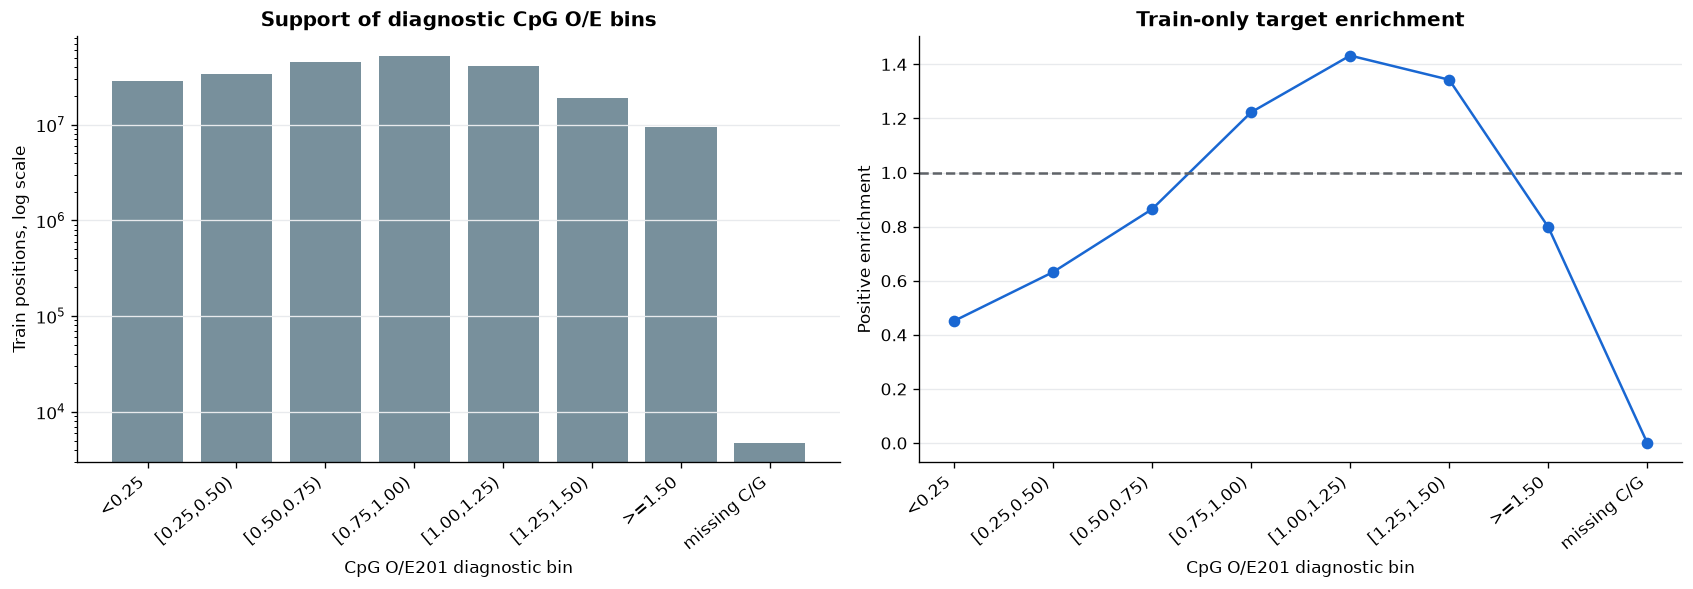

In [8]:
train_cpg_enrichment = cpg_enrichment_table(train_cpg_counts)
display(train_cpg_enrichment)

fig_train_cpg, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
x = np.arange(len(train_cpg_enrichment))
axes[0].bar(x, train_cpg_enrichment["positions"], color="#78909C")
axes[0].set_yscale("log")
axes[0].set_ylabel("Train positions, log scale")
axes[0].set_title("Support of diagnostic CpG O/E bins")
axes[1].plot(x, train_cpg_enrichment["enrichment"], marker="o", color="#1967D2")
axes[1].axhline(1.0, color="#5F6368", linestyle="--")
axes[1].set_ylabel("Positive enrichment")
axes[1].set_title("Train-only target enrichment")
for ax in axes:
    ax.set_xticks(x, train_cpg_enrichment["cpg_oe_bin"], rotation=40, ha="right")
    ax.set_xlabel("CpG O/E201 diagnostic bin")
    ax.grid(axis="y", color="#E8EAED")
plt.show()


In [9]:
design = hierarchical_kmer_design(CONFIG)
train_aggregate_preview = aggregate_cpg_likelihood(
    train_cpg_counts,
    design,
    config=CONFIG,
)
aggregate_report = pd.Series({
    "EXP-007_main_effect_columns": 4379,
    "CpG_OE201_bin_columns": 7,
    "candidate_columns": train_aggregate_preview.matrix.shape[1],
    "aggregate_binary_rows": len(train_aggregate_preview.rows),
    "represented_positions": int(train_aggregate_preview.rows["population_count"].sum()),
    "matrix_memory_mib": (
        train_aggregate_preview.matrix.data.nbytes
        + train_aggregate_preview.matrix.indices.nbytes
        + train_aggregate_preview.matrix.indptr.nbytes
    ) / 2**20,
}, name="value").to_frame()
display(aggregate_report)
assert train_aggregate_preview.matrix.shape[1] == 4386
assert int(train_aggregate_preview.rows["population_count"].sum()) == expected_train
del train_aggregate_preview


,value
EXP-007_main_effect_columns,4.379000e+03
CpG_OE201_bin_columns,7.000000e+00
candidate_columns,4.386000e+03
aggregate_binary_rows,2.922400e+05
represented_positions,2.280642e+08
matrix_memory_mib,1.680433e+01


In [10]:
cv_plan = pd.Series({
    "folds": CONFIG.cv_folds,
    "C_values": len(CONFIG.C_grid),
    "planned_fits": CONFIG.cv_folds * len(CONFIG.C_grid),
    "C_grid": CONFIG.C_grid,
    "max_iter": CONFIG.max_iter,
    "tol": CONFIG.tol,
    "candidate_columns": 4386,
    "threadpoolctl_during_fit": False,
}, name="value").to_frame()
display(cv_plan)
assert CONFIG.cv_folds * len(CONFIG.C_grid) == 15


,value
folds,3
C_values,5
planned_fits,15
C_grid,"(0.0001, 0.0002, 0.0003, 0.0005, 0.001)"
max_iter,2000
tol,0.0
candidate_columns,4386
threadpoolctl_during_fit,False


# STOP 1 — перед обучением

Проверьте формулу CpG O/E, train enrichment, exact population,
`candidate_columns=4386` и план `5 × 3 = 15 fits`. Следующая ячейка
действительно обучает модели и печатает прогресс `01/15 … 15/15`.


In [11]:
started = time.monotonic()
cv_results = cross_validate_cpg_logistic(
    train_cpg_counts,
    fold_assignment,
    config=CONFIG,
    verbose=True,
)
cv_seconds = time.monotonic() - started
assert len(cv_results) == 15
print(f"Train-only CV finished in {cv_seconds:.2f} s")
display(cv_results.head())


[01/15] fold=0 C=0.0001 AP=0.002960845 iter=222 time=2.53s converged=True
[02/15] fold=0 C=0.0002 AP=0.002954275 iter=307 time=3.42s converged=True
[03/15] fold=0 C=0.0003 AP=0.002946861 iter=365 time=4.08s converged=True
[04/15] fold=0 C=0.0005 AP=0.002936383 iter=435 time=4.95s converged=True
[05/15] fold=0 C=0.001 AP=0.002923221 iter=561 time=6.31s converged=True
[06/15] fold=1 C=0.0001 AP=0.002470956 iter=217 time=2.42s converged=True
[07/15] fold=1 C=0.0002 AP=0.002466666 iter=305 time=3.44s converged=True
[08/15] fold=1 C=0.0003 AP=0.002461691 iter=369 time=4.25s converged=True
[09/15] fold=1 C=0.0005 AP=0.002455050 iter=415 time=4.66s converged=True
[10/15] fold=1 C=0.001 AP=0.002446678 iter=534 time=6.11s converged=True
[11/15] fold=2 C=0.0001 AP=0.002585512 iter=216 time=2.39s converged=True
[12/15] fold=2 C=0.0002 AP=0.002581874 iter=295 time=3.42s converged=True
[13/15] fold=2 C=0.0003 AP=0.002576383 iter=350 time=3.97s converged=True
[14/15] fold=2 C=0.0005 AP=0.002569520 i

,C,fold,validation_contigs,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,iterations,converged,fit_seconds,aggregate_rows,warnings,cpg_bin_coefficient_0,cpg_bin_coefficient_1,cpg_bin_coefficient_2,cpg_bin_coefficient_3,cpg_bin_coefficient_4,cpg_bin_coefficient_5,cpg_bin_coefficient_6,cpg_bin_coefficient_7
0,0.0001,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",EXP-009 EXP-007 + CpG O/E201,0.002961,0.099449,0.586717,0.588003,75423552,61433,0.000815,222,True,2.532,276605,,-0.437749,-0.388063,-0.239363,0.0,0.178991,0.168627,-0.147076,-0.027836
1,0.0001,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",EXP-009 EXP-007 + CpG O/E201,0.002471,0.096158,0.588843,0.594267,77195444,56300,0.000729,217,True,2.422,277785,,-0.458558,-0.437696,-0.260439,0.0,0.140105,0.134131,-0.189170,-0.027907
2,0.0001,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",EXP-009 EXP-007 + CpG O/E201,0.002586,0.098278,0.586794,0.585882,75445164,52710,0.000699,216,True,2.391,279679,,-0.441734,-0.379505,-0.227366,0.0,0.160224,0.165919,-0.102644,-0.031920
3,0.0002,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",EXP-009 EXP-007 + CpG O/E201,0.002954,0.100197,0.585476,0.587920,75423552,61433,0.000815,307,True,3.422,276605,,-0.437981,-0.389004,-0.240056,0.0,0.178847,0.168119,-0.148257,-0.039556
4,0.0002,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",EXP-009 EXP-007 + CpG O/E201,0.002467,0.096958,0.587579,0.594231,77195444,56300,0.000729,305,True,3.437,277785,,-0.459256,-0.438814,-0.261130,0.0,0.139678,0.134080,-0.190297,-0.046452


In [12]:
cv_summary = summarise_cv(cv_results)
nonconverged = cv_summary.loc[~cv_summary["all_folds_converged"].astype(bool)]
display(cv_summary.style.format({
    "mean_average_precision": "{:.9f}",
    "std_average_precision": "{:.9f}",
    "mean_epic_spearman": "{:.6f}",
    "std_epic_spearman": "{:.6f}",
    "mean_balanced_log_loss": "{:.6f}",
    "total_fit_seconds": "{:.2f}",
}))
if len(nonconverged):
    display(Markdown(
        "**Несошедшиеся C исключаются из выбора:** "
        + ", ".join(map(str, nonconverged["C"]))
    ))
assert cv_summary["all_folds_converged"].any(), "Ни один C не сошёлся"


,C,mean_average_precision,std_average_precision,mean_epic_spearman,std_epic_spearman,mean_balanced_log_loss,all_folds_converged,max_iterations,total_fit_seconds
0,0.000100,0.002672438,0.000256252,0.097961,0.001668,0.589384,True,222,7.35
1,0.000200,0.002667605,0.000254858,0.098760,0.001650,0.589319,True,307,10.28
2,0.000300,0.002661645,0.000253573,0.099084,0.001605,0.589511,True,369,12.30
3,0.000500,0.002653651,0.000251453,0.099353,0.001537,0.589921,True,466,15.05
4,0.001000,0.002643294,0.000248956,0.099519,0.001437,0.590584,True,561,18.59


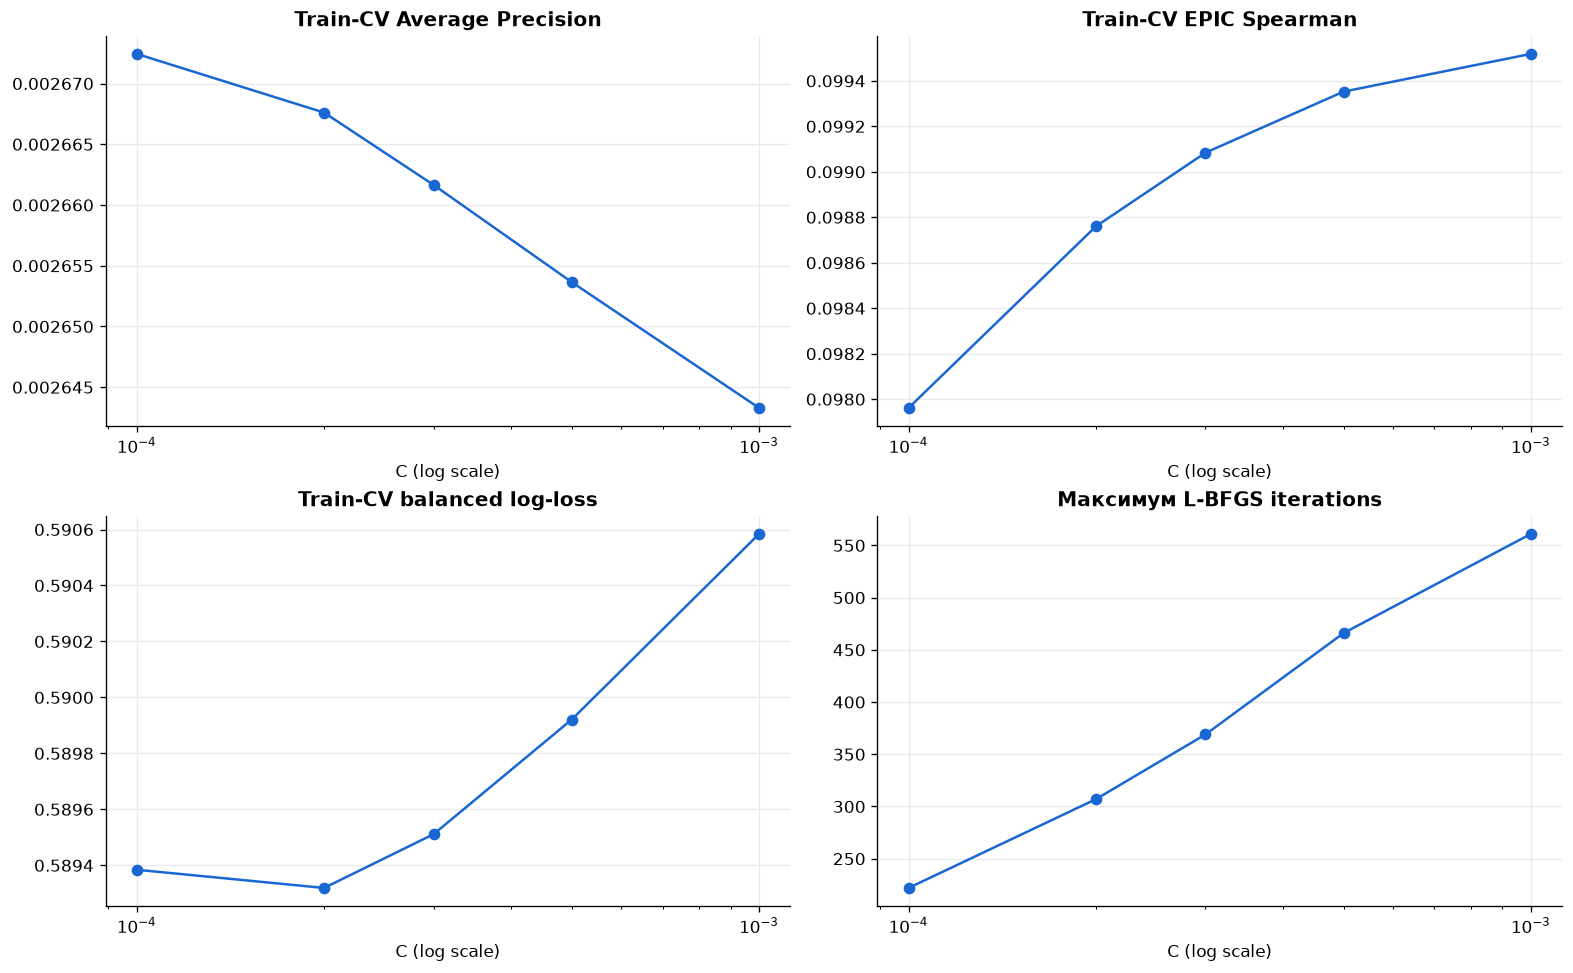

In [13]:
fig_cv, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
panels = [
    ("mean_average_precision", "Train-CV Average Precision", axes[0, 0]),
    ("mean_epic_spearman", "Train-CV EPIC Spearman", axes[0, 1]),
    ("mean_balanced_log_loss", "Train-CV balanced log-loss", axes[1, 0]),
    ("max_iterations", "Максимум L-BFGS iterations", axes[1, 1]),
]
for column, title, ax in panels:
    ax.plot(cv_summary["C"], cv_summary[column], marker="o", color="#1967D2")
    failed = ~cv_summary["all_folds_converged"].astype(bool)
    ax.scatter(
        cv_summary.loc[failed, "C"],
        cv_summary.loc[failed, column],
        color="#D93025",
        label="not converged",
        zorder=3,
    )
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_title(title)
    ax.grid(color="#E8EAED")
    if failed.any():
        ax.legend(frameon=False)
plt.show()


In [14]:
selected = select_regularization(
    cv_summary,
    relative_ap_tolerance=CONFIG.near_best_relative_ap,
)
SELECTED_C = float(selected["C"])
display(selected.to_frame("selected_value"))
print(f"Frozen candidate C before validation: {SELECTED_C:g}")


,selected_value
C,0.0001
mean_average_precision,0.002672
std_average_precision,0.000256
mean_epic_spearman,0.097961
std_epic_spearman,0.001668
mean_balanced_log_loss,0.589384
all_folds_converged,True
max_iterations,222
total_fit_seconds,7.345


Frozen candidate C before validation: 0.0001


,fold,validation_contigs,candidate_average_precision,candidate_epic_spearman,candidate_converged,exp007_validation_contigs,exp007_average_precision,exp007_epic_spearman,ap_delta,relative_ap_delta,spearman_delta
0,0,"NC_064035.1,NC_064043.1,NC_064048.1",0.002960845,0.099449,True,"NC_064035.1,NC_064043.1,NC_064048.1",0.002579426,0.090699,+0.000381419,+14.79%,+0.008750
1,1,"NC_064036.1,NC_064038.1,NC_064045.1",0.002470956,0.096158,True,"NC_064036.1,NC_064038.1,NC_064045.1",0.002167184,0.085675,+0.000303771,+14.02%,+0.010483
2,2,"NC_064039.1,NC_064040.1,NC_064047.1",0.002585512,0.098278,True,"NC_064039.1,NC_064040.1,NC_064047.1",0.002224279,0.089957,+0.000361233,+16.24%,+0.008320


,passed
all candidate fits converged,True
mean AP > EXP-007,True
AP wins on at least 2/3 folds,True
mean Spearman >= EXP-007,True


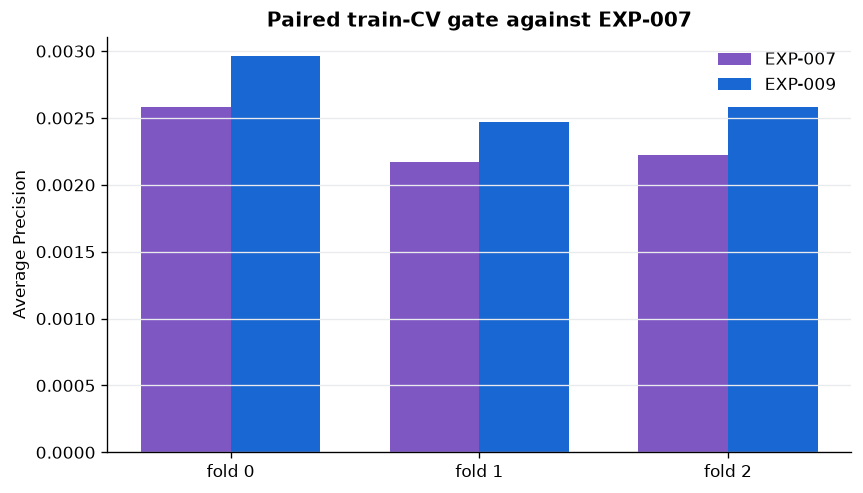

CV gate passed: True


In [15]:
EXP007_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-007/run_001"
exp007_metadata = json.loads((EXP007_DIR / "metadata.json").read_text(encoding="utf-8"))
exp007_cv_results = pd.read_csv(EXP007_DIR / "cv_results.csv")
EXP007_SELECTED_C = float(exp007_metadata["parameters"]["selected_C"])

candidate_cv_selected = cv_results.loc[
    np.isclose(cv_results["C"], SELECTED_C),
    ["fold", "validation_contigs", "average_precision", "epic_spearman", "converged"],
].rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
    "converged": "candidate_converged",
})
exp007_cv_selected = exp007_cv_results.loc[
    np.isclose(exp007_cv_results["C"], EXP007_SELECTED_C),
    ["fold", "validation_contigs", "average_precision", "epic_spearman"],
].rename(columns={
    "validation_contigs": "exp007_validation_contigs",
    "average_precision": "exp007_average_precision",
    "epic_spearman": "exp007_epic_spearman",
})
paired_cv_gate = candidate_cv_selected.merge(
    exp007_cv_selected, on="fold", validate="one_to_one"
)
assert (
    paired_cv_gate["validation_contigs"]
    == paired_cv_gate["exp007_validation_contigs"]
).all(), "EXP-009 and EXP-007 must be compared on identical CV contigs"
paired_cv_gate["ap_delta"] = (
    paired_cv_gate["candidate_average_precision"]
    - paired_cv_gate["exp007_average_precision"]
)
paired_cv_gate["relative_ap_delta"] = (
    paired_cv_gate["candidate_average_precision"]
    / paired_cv_gate["exp007_average_precision"] - 1
)
paired_cv_gate["spearman_delta"] = (
    paired_cv_gate["candidate_epic_spearman"]
    - paired_cv_gate["exp007_epic_spearman"]
)
display(paired_cv_gate.style.format({
    "candidate_average_precision": "{:.9f}",
    "exp007_average_precision": "{:.9f}",
    "ap_delta": "{:+.9f}",
    "relative_ap_delta": "{:+.2%}",
    "candidate_epic_spearman": "{:.6f}",
    "exp007_epic_spearman": "{:.6f}",
    "spearman_delta": "{:+.6f}",
}))
cv_gate_checks = pd.Series({
    "all candidate fits converged": paired_cv_gate["candidate_converged"].all(),
    "mean AP > EXP-007": (
        paired_cv_gate["candidate_average_precision"].mean()
        > paired_cv_gate["exp007_average_precision"].mean()
    ),
    "AP wins on at least 2/3 folds": int((paired_cv_gate["ap_delta"] > 0).sum()) >= 2,
    "mean Spearman >= EXP-007": (
        paired_cv_gate["candidate_epic_spearman"].mean()
        >= paired_cv_gate["exp007_epic_spearman"].mean()
    ),
}, name="passed")
CV_GATE_PASSED = bool(cv_gate_checks.all())
display(cv_gate_checks.to_frame())

fig_paired_cv, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(paired_cv_gate))
width = 0.36
ax.bar(x - width/2, paired_cv_gate["exp007_average_precision"], width,
       label="EXP-007", color="#7E57C2")
ax.bar(x + width/2, paired_cv_gate["candidate_average_precision"], width,
       label="EXP-009", color="#1967D2")
ax.set_xticks(x, [f"fold {value}" for value in paired_cv_gate["fold"]])
ax.set_ylabel("Average Precision")
ax.set_title("Paired train-CV gate against EXP-007")
ax.legend(frameon=False)
ax.grid(axis="y", color="#E8EAED")
plt.show()
print("CV gate passed:", CV_GATE_PASSED)


,fold,cpg_bin_code,cpg_oe_bin,is_reference,coefficient,odds_multiplier
0,0,0,<0.25,False,-0.437749,0.6455
1,0,1,"[0.25,0.50)",False,-0.388063,0.6784
2,0,2,"[0.50,0.75)",False,-0.239363,0.7871
3,0,3,"[0.75,1.00)",True,+0.000000,1.0000
4,0,4,"[1.00,1.25)",False,+0.178991,1.1960
5,0,5,"[1.25,1.50)",False,+0.168627,1.1837
6,0,6,>=1.50,False,-0.147076,0.8632
7,0,7,missing C/G,False,-0.027836,0.9725
8,1,0,<0.25,False,-0.458558,0.6322
9,1,1,"[0.25,0.50)",False,-0.437696,0.6455


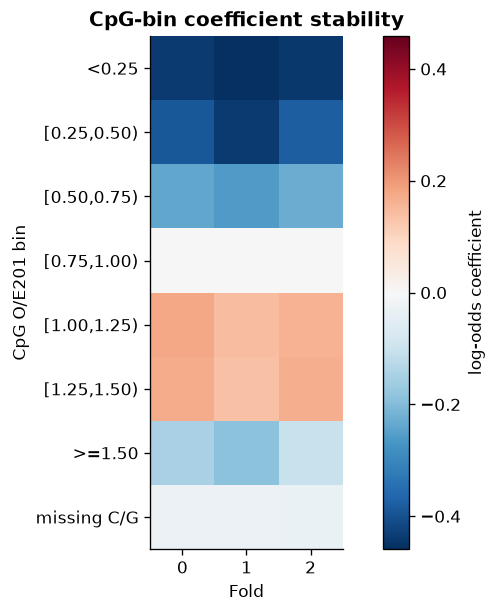

In [16]:
selected_cv_cpg_coefs = selected_cv_cpg_coefficients(
    cv_results,
    C=SELECTED_C,
)
display(selected_cv_cpg_coefs.style.format({
    "coefficient": "{:+.6f}",
    "odds_multiplier": "{:.4f}",
}))

coefficient_grid = selected_cv_cpg_coefs.pivot(
    index="cpg_oe_bin", columns="fold", values="coefficient"
).reindex(CPG_DIAGNOSTIC_LABELS)
limit = max(0.01, float(np.nanmax(np.abs(coefficient_grid.to_numpy()))))
fig_cv_cpg, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
image = ax.imshow(coefficient_grid, cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(range(len(coefficient_grid.columns)), coefficient_grid.columns)
ax.set_yticks(range(len(coefficient_grid.index)), coefficient_grid.index)
ax.set_xlabel("Fold")
ax.set_ylabel("CpG O/E201 bin")
ax.set_title("CpG-bin coefficient stability")
fig_cv_cpg.colorbar(image, ax=ax, label="log-odds coefficient")
plt.show()


# STOP 2 — paired CV gate

Проверьте mean AP, число fold-побед, mean Spearman и устойчивость
CpG-bin коэффициентов. Даже при непройденном gate эксперимент можно один раз
довести до validation и сохранить, но такой run не получит `adopt`.


In [17]:
ALLOW_EXPLORATORY_COMPLETION = True
PROTOCOL_STATUS = (
    "confirmatory"
    if CV_GATE_PASSED
    else "exploratory_after_failed_cv_gate"
)
if not CV_GATE_PASSED:
    assert ALLOW_EXPLORATORY_COMPLETION
    display(Markdown(
        "**CV gate не пройден.** Продолжаем ровно один раз только для "
        "сохранения полного отрицательного результата. Такой run не "
        "может получить решение `adopt`."
    ))
print("Protocol status:", PROTOCOL_STATUS)


Protocol status: confirmatory


In [18]:
print(f"Starting full-train fit with C={SELECTED_C:g} ...", flush=True)
started = time.monotonic()
final_fit = fit_cpg_logistic(
    train_cpg_counts,
    C=SELECTED_C,
    config=CONFIG,
    design=design,
)
full_fit_seconds = time.monotonic() - started
display(final_fit.fit_report)
assert bool(final_fit.fit_report.iloc[0]["converged"]), (
    "Final candidate did not converge; record the technical failure."
)
print(f"Full-train candidate fit in {full_fit_seconds:.2f} s")


Starting full-train fit with C=0.0001 ...


,C,solver,penalty,tol,iterations,max_iter,converged,fit_seconds,aggregate_rows,features,represented_positions,represented_positives,cpg_bin_features,reference_gc_bin,reference_cpg_bin,intercept,warnings
0,0.0001,lbfgs,l2,1.000000e-08,262,2000,True,3.109,292240,4386,228064160,170443,7,"[0.35,0.40)","[0.75,1.00)",-0.401572,


Full-train candidate fit in 3.45 s


In [19]:
final_cpg_coefficient = final_fit.coefficient_table.loc[
    final_fit.coefficient_table["feature_group"] == "CpG O/E201 bin"
].copy()
final_cpg_coefficient["odds_multiplier"] = np.exp(
    final_cpg_coefficient["coefficient"]
)
display(final_cpg_coefficient)


,feature_index,level_k,category_code,category,feature_name,feature_group,coefficient,absolute_coefficient,odds_multiplier
4379,4379,<NA>,0,<0.25,cpg_oe201_bin=<0.25,CpG O/E201 bin,-0.446315,0.446315,0.639982
4380,4380,<NA>,1,"[0.25,0.50)","cpg_oe201_bin=[0.25,0.50)",CpG O/E201 bin,-0.401522,0.401522,0.669301
4381,4381,<NA>,2,"[0.50,0.75)","cpg_oe201_bin=[0.50,0.75)",CpG O/E201 bin,-0.242373,0.242373,0.784763
4382,4382,<NA>,4,"[1.00,1.25)","cpg_oe201_bin=[1.00,1.25)",CpG O/E201 bin,0.158934,0.158934,1.172260
4383,4383,<NA>,5,"[1.25,1.50)","cpg_oe201_bin=[1.25,1.50)",CpG O/E201 bin,0.155733,0.155733,1.168515
4384,4384,<NA>,6,>=1.50,cpg_oe201_bin=>=1.50,CpG O/E201 bin,-0.146230,0.146230,0.863959
4385,4385,<NA>,7,missing C/G,cpg_oe201_bin=missing C/G,CpG O/E201 bin,-0.038310,0.038310,0.962414


# STOP 3 — зафиксированный одноразовый validation

Формула CpG O/E, fixed bins, reference bin, grid, выбранный `C`,
paired gate и final fit зафиксированы. После следующей ячейки ничего
менять нельзя; новая форма CpG потребует EXP-010.


In [20]:
started = time.monotonic()
validation_cpg_counts = split_kmer_cpg_counts(
    split,
    sequences,
    "validation",
    config=CONFIG,
    verbose=True,
)
validation_count_seconds = time.monotonic() - started
validation_kmer_counts = kmer_counts_from_cpg_counts(validation_cpg_counts)
validation_count_diagnostics = pd.Series({
    "represented_positions": int(
        validation_cpg_counts.totals["total_positions"].sum()
    ),
    "joint_rows": len(validation_cpg_counts.totals),
    "positive_rows": len(validation_cpg_counts.positives),
}, name="value").to_frame()
display(validation_count_diagnostics)
print(f"Validation counted in {validation_count_seconds:.2f} s")


[01/06] NC_064034.1 strand=+ positions=16,974,557 joint_rows=209,447 part_time=6.0s elapsed=6.1s
[02/06] NC_064034.1 strand=- positions=16,974,557 joint_rows=209,447 part_time=6.0s elapsed=12.2s
[03/06] NC_064041.1 strand=+ positions=12,073,377 joint_rows=205,532 part_time=4.7s elapsed=16.9s
[04/06] NC_064041.1 strand=- positions=12,073,377 joint_rows=205,425 part_time=4.9s elapsed=21.9s
[05/06] NC_064042.1 strand=+ positions=12,855,809 joint_rows=208,963 part_time=4.8s elapsed=26.8s
[06/06] NC_064042.1 strand=- positions=12,855,809 joint_rows=209,090 part_time=4.8s elapsed=31.7s


,value
represented_positions,83807486
joint_rows,1247904
positive_rows,56205


Validation counted in 32.61 s


In [21]:
candidate_evaluation = evaluate_cpg_logistic(
    validation_cpg_counts,
    final_fit,
    config=CONFIG,
    variant="EXP-009 EXP-007 + CpG O/E201",
)
candidate_row = candidate_evaluation.metric_summary.iloc[0]
display(candidate_evaluation.metric_summary)
display(candidate_evaluation.per_contig_metrics)


,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence
0,overall,EXP-009 EXP-007 + CpG O/E201,0.002364,0.115517,0.59185,0.591031,83807486,56205,0.000671


,contig,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence
0,NC_064034.1,EXP-009 EXP-007 + CpG O/E201,0.002576,0.130304,0.590479,0.585948,33949114,23529,0.000693
1,NC_064041.1,EXP-009 EXP-007 + CpG O/E201,0.001957,0.143246,0.590999,0.593304,24146754,13984,0.000579
2,NC_064042.1,EXP-009 EXP-007 + CpG O/E201,0.002475,0.137105,0.594460,0.595853,25711618,18692,0.000727


In [22]:
lookup_fit = fit_kmer_lookup(train_kmer_counts, LOOKUP_CONFIG)
lookup_evaluation = evaluate_kmer_lookup(validation_kmer_counts, lookup_fit)
exp003_row = lookup_evaluation.metric_summary.loc[
    lookup_evaluation.metric_summary["k"] == 6
].iloc[0]
display(exp003_row.to_frame("EXP-003"))


,EXP-003
segment,overall
segment_value,overall
k,6
variant,6mer_lookup
average_precision,0.001601
epic_spearman,0.097186
positions,83807486
positives,56205
prevalence,0.000671
unique_score_levels,4097


In [23]:
exp007_per_contig = pd.read_csv(EXP007_DIR / "per_contig_metrics.csv")
exp007_pr_all = pd.read_csv(EXP007_DIR / "precision_recall.csv")
exp007_pr = exp007_pr_all.loc[
    exp007_pr_all["variant"] == "EXP-007 binned GC201"
].copy()
exp007_ap = float(exp007_metadata["metrics"]["candidate_average_precision"])
exp007_spearman = float(exp007_metadata["metrics"]["candidate_epic_spearman"])
display(pd.Series({
    "EXP-007 AP": exp007_ap,
    "EXP-007 Spearman": exp007_spearman,
    "EXP-007 decision": exp007_metadata["run"]["decision"],
}, name="value").to_frame())


C:\Users\lasvi\AppData\Local\Temp\ipykernel_57732\270846052.py:2: DtypeWarning: Columns (0: segment) have mixed types. Specify dtype option on import or set low_memory=False.
  exp007_pr_all = pd.read_csv(EXP007_DIR / "precision_recall.csv")


,value
EXP-007 AP,0.002054
EXP-007 Spearman,0.104302
EXP-007 decision,adopt


In [24]:
metric_summary = pd.DataFrame([
    {
        "variant": "EXP-003 6-mer lookup",
        "average_precision": float(exp003_row["average_precision"]),
        "epic_spearman": float(exp003_row["epic_spearman"]),
    },
    {
        "variant": "EXP-007 binned GC201",
        "average_precision": exp007_ap,
        "epic_spearman": exp007_spearman,
    },
    {
        "variant": "EXP-009 CpG O/E201",
        "average_precision": float(candidate_row["average_precision"]),
        "epic_spearman": float(candidate_row["epic_spearman"]),
    },
])
display(metric_summary)

exp003_contigs = lookup_evaluation.per_contig_metrics.loc[
    lookup_evaluation.per_contig_metrics["k"] == 6,
    ["segment_value", "average_precision", "epic_spearman"],
].rename(columns={
    "segment_value": "contig",
    "average_precision": "exp003_average_precision",
    "epic_spearman": "exp003_epic_spearman",
})
exp007_contigs = exp007_per_contig.rename(columns={
    "candidate_average_precision": "exp007_average_precision",
    "candidate_epic_spearman": "exp007_epic_spearman",
})[["contig", "exp007_average_precision", "exp007_epic_spearman"]]
candidate_contigs = candidate_evaluation.per_contig_metrics.rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
})[["contig", "candidate_average_precision", "candidate_epic_spearman"]]
per_contig_metrics = (
    exp003_contigs
    .merge(exp007_contigs, on="contig", validate="one_to_one")
    .merge(candidate_contigs, on="contig", validate="one_to_one")
)
display(per_contig_metrics)


,variant,average_precision,epic_spearman
0,EXP-003 6-mer lookup,0.001601,0.097186
1,EXP-007 binned GC201,0.002054,0.104302
2,EXP-009 CpG O/E201,0.002364,0.115517


,contig,exp003_average_precision,exp003_epic_spearman,exp007_average_precision,exp007_epic_spearman,candidate_average_precision,candidate_epic_spearman
0,NC_064034.1,0.001717,0.109397,0.002241,0.123295,0.002576,0.130304
1,NC_064041.1,0.001381,0.120721,0.001710,0.127176,0.001957,0.143246
2,NC_064042.1,0.001655,0.115426,0.002137,0.123564,0.002475,0.137105


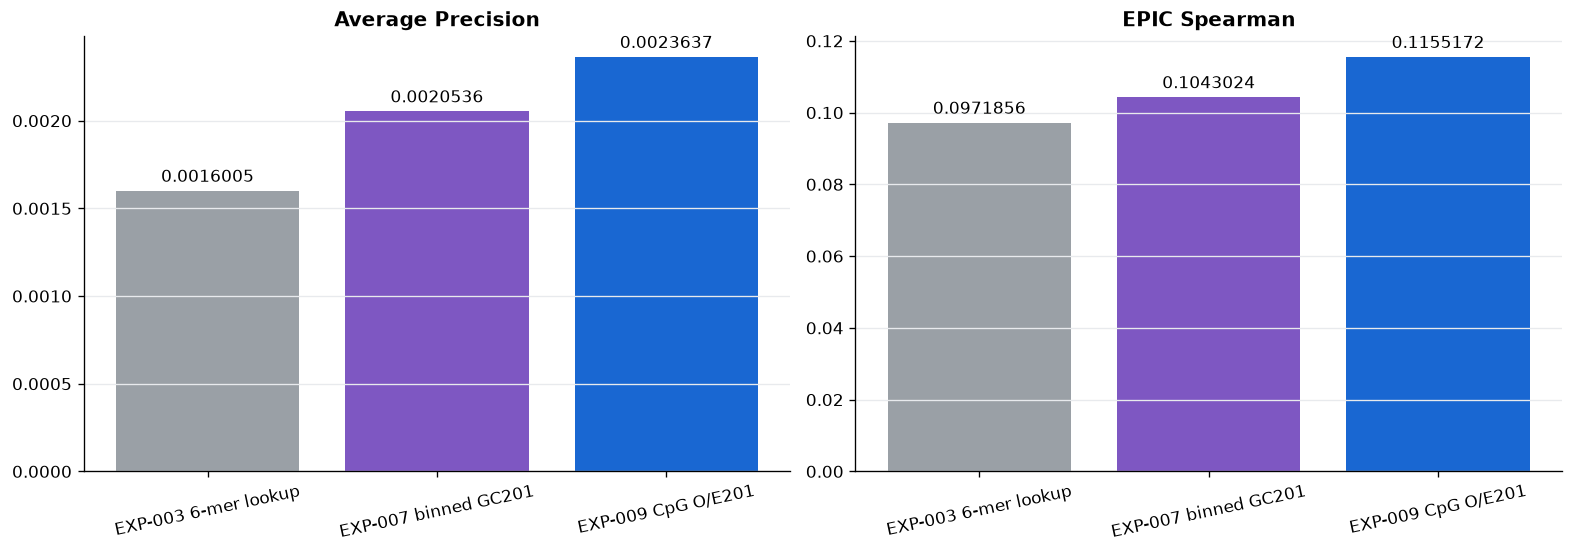

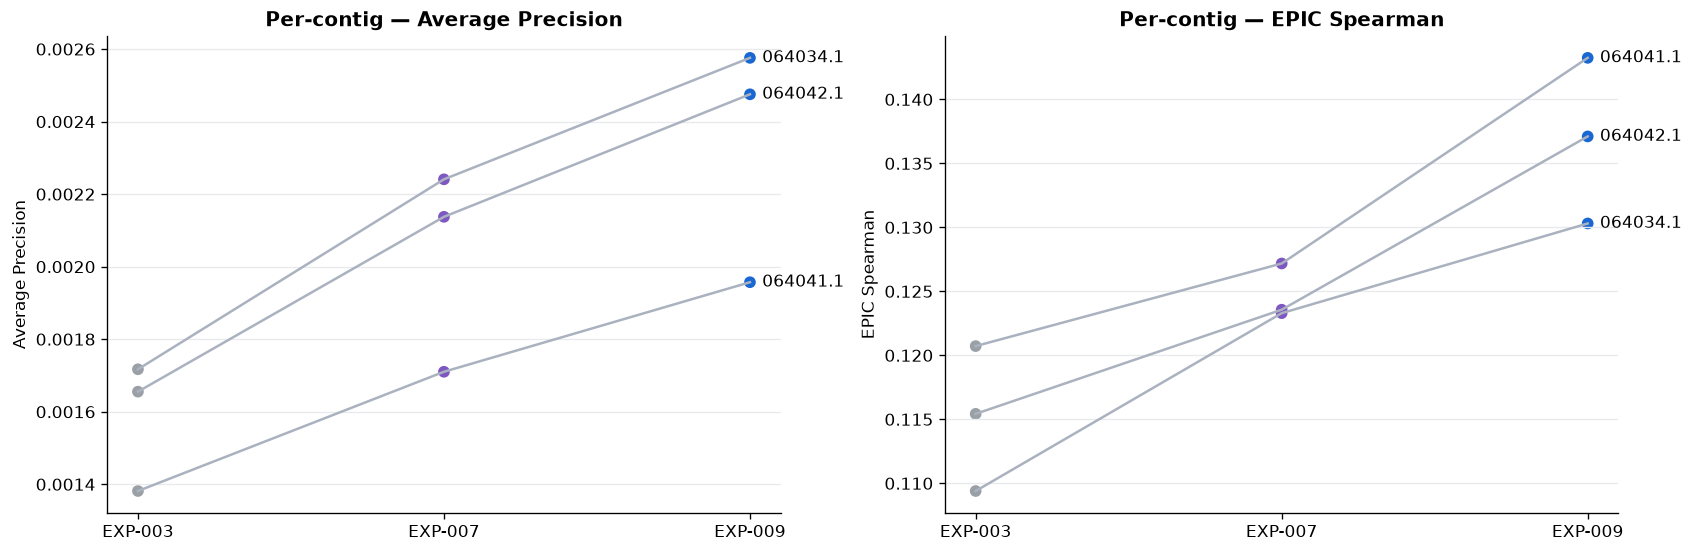

In [25]:
colors = ["#9AA0A6", "#7E57C2", "#1967D2"]
fig_metrics, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    bars = ax.bar(metric_summary["variant"], metric_summary[metric], color=colors)
    ax.bar_label(bars, fmt="%.7f", padding=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=12)
    ax.grid(axis="y", color="#E8EAED")
plt.show()

fig_contigs, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for ax, metric, label in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    columns = [f"exp003_{metric}", f"exp007_{metric}", f"candidate_{metric}"]
    for _, row in per_contig_metrics.iterrows():
        values = [row[column] for column in columns]
        ax.plot(range(3), values, color="#AAB2C0")
        ax.scatter(range(3), values, color=colors)
        ax.text(2.04, values[-1], row["contig"].replace("NC_", ""), va="center")
    ax.set_xticks(range(3), ["EXP-003", "EXP-007", "EXP-009"])
    ax.set_ylabel(label)
    ax.set_title(f"Per-contig — {label}")
    ax.grid(axis="y", color="#E8EAED")
plt.show()


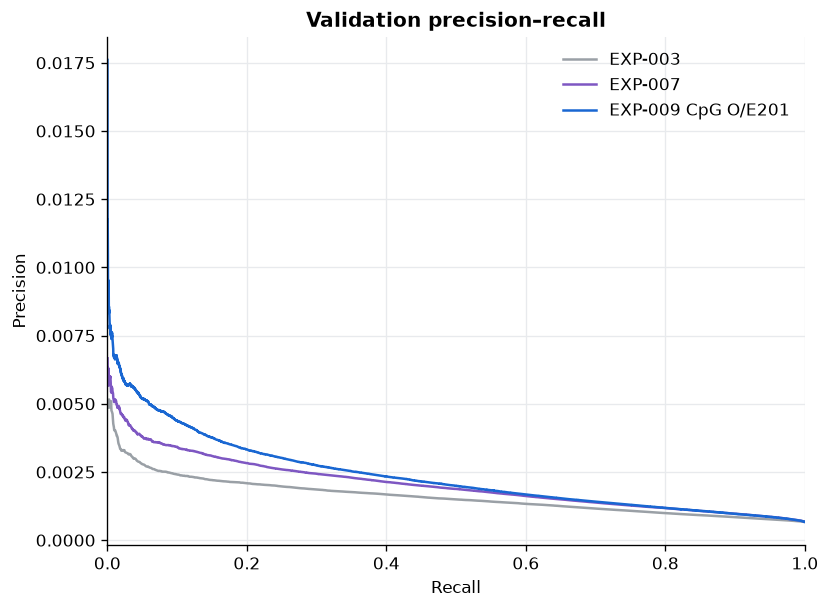

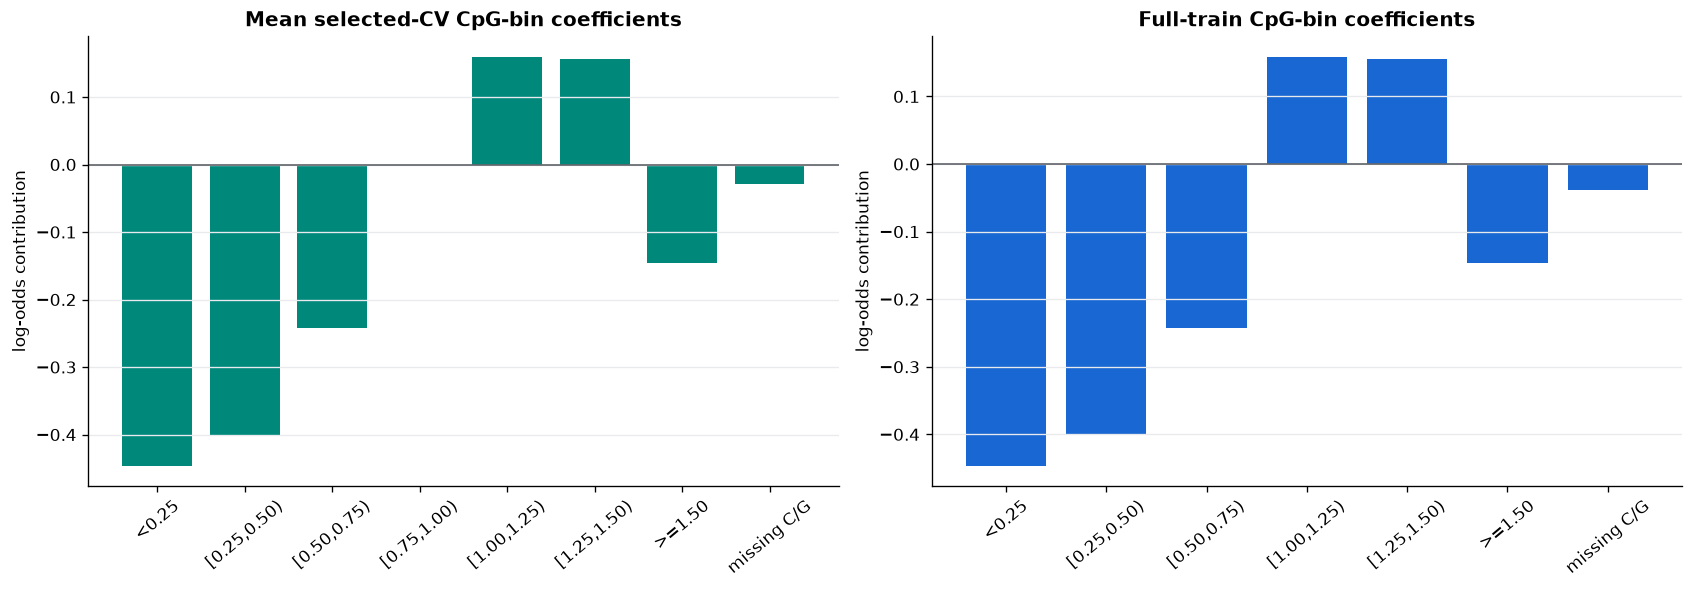

In [26]:
reference_pr = lookup_evaluation.precision_recall.loc[
    lookup_evaluation.precision_recall["k"] == 6
].copy()
candidate_pr = candidate_evaluation.precision_recall.copy()

fig_pr, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(reference_pr["recall"], reference_pr["precision"],
        color="#9AA0A6", label="EXP-003")
ax.plot(exp007_pr["recall"], exp007_pr["precision"],
        color="#7E57C2", label="EXP-007")
ax.plot(candidate_pr["recall"], candidate_pr["precision"],
        color="#1967D2", label="EXP-009 CpG O/E201")
ax.set_xlim(0, 1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation precision–recall")
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
plt.show()

fig_coefficients, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
cv_mean_coefficients = selected_cv_cpg_coefs.groupby(
    "cpg_oe_bin", as_index=False, sort=False
)["coefficient"].mean()
axes[0].bar(
    cv_mean_coefficients["cpg_oe_bin"],
    cv_mean_coefficients["coefficient"],
    color="#00897B",
)
axes[0].axhline(0, color="#5F6368", linewidth=1)
axes[0].set_title("Mean selected-CV CpG-bin coefficients")
axes[1].bar(
    final_cpg_coefficient["category"],
    final_cpg_coefficient["coefficient"],
    color="#1967D2",
)
axes[1].axhline(0, color="#5F6368", linewidth=1)
axes[1].set_title("Full-train CpG-bin coefficients")
for ax in axes:
    ax.set_ylabel("log-odds contribution")
    ax.tick_params(axis="x", rotation=40)
    ax.grid(axis="y", color="#E8EAED")
plt.show()


## 7. Решение

EXP-007 — champion reference. EXP-008 показан только как сохранённый
отрицательный эксперимент и не входит в candidate pipeline.


In [27]:
candidate_ap = float(candidate_row["average_precision"])
candidate_spearman = float(candidate_row["epic_spearman"])
exp003_ap = float(exp003_row["average_precision"])
exp003_spearman = float(exp003_row["epic_spearman"])

champion_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["exp007_average_precision"]
).sum())
validation_checks = pd.Series({
    "relative AP gain vs EXP-007 >= 1%": candidate_ap / exp007_ap - 1 >= 0.01,
    "Spearman >= EXP-007": candidate_spearman >= exp007_spearman,
    "AP wins vs EXP-007 on at least 2/3 contigs": champion_ap_wins >= 2,
}, name="passed")
champion_checks = pd.concat([
    pd.Series({"train-CV gate passed": CV_GATE_PASSED}, name="passed"),
    validation_checks,
])
display(Markdown("### Champion gate vs EXP-007"))
display(champion_checks.to_frame())

VALIDATION_CHECKS_PASSED = bool(validation_checks.all())
if CV_GATE_PASSED and VALIDATION_CHECKS_PASSED:
    DECISION = "adopt"
elif VALIDATION_CHECKS_PASSED:
    DECISION = "iterate"
else:
    DECISION = "reject"
INTERPRETATION = (
    f"CpG O/E201 changed AP vs EXP-007 from {exp007_ap:.9f} "
    f"to {candidate_ap:.9f} ({candidate_ap / exp007_ap - 1:+.2%}) and "
    f"Spearman from {exp007_spearman:.6f} to {candidate_spearman:.6f}; "
    f"train-CV gate passed: {CV_GATE_PASSED}; protocol: {PROTOCOL_STATUS}. "
    f"Decision: {DECISION}."
)
display(Markdown(f"**Decision: `{DECISION}`.** {INTERPRETATION}"))


### Champion gate vs EXP-007

,passed
train-CV gate passed,True
relative AP gain vs EXP-007 >= 1%,True
Spearman >= EXP-007,True
AP wins vs EXP-007 on at least 2/3 contigs,True


**Decision: `adopt`.** CpG O/E201 changed AP vs EXP-007 from 0.002053635 to 0.002363735 (+15.10%) and Spearman from 0.104302 to 0.115517; train-CV gate passed: True; protocol: confirmatory. Decision: adopt.

## 8. Сохранение

Эта ячейка создаёт immutable `EXP-009/run_001` при любом содержательном
исходе: `adopt`, `iterate` или `reject`.


In [32]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plot_objects = {
    "01_train_cpg_enrichment.png": fig_train_cpg,
    "02_train_cv_diagnostics.png": fig_cv,
    "03_paired_cv_gate.png": fig_paired_cv,
    "04_cv_cpg_coefficients.png": fig_cv_cpg,
    "05_validation_metrics.png": fig_metrics,
    "06_per_contig_metrics.png": fig_contigs,
    "07_precision_recall.png": fig_pr,
    "08_final_cpg_coefficient.png": fig_coefficients,
}
for filename, figure in plot_objects.items():
    figure.savefig(PLOT_DIR / filename, dpi=170, bbox_inches="tight", facecolor="white")

criteria_table = champion_checks.rename("passed").to_frame().assign(
    comparison="EXP-007"
).rename_axis("criterion").reset_index()
precision_recall = pd.concat([
    reference_pr.assign(variant="EXP-003 6-mer lookup"),
    exp007_pr.assign(variant="EXP-007 binned GC201"),
    candidate_pr.assign(variant="EXP-009 CpG O/E201"),
], ignore_index=True)
tables = {
    "train_count_diagnostics.csv": train_count_diagnostics,
    "validation_count_diagnostics.csv": validation_count_diagnostics,
    "train_cpg_enrichment.csv": train_cpg_enrichment,
    "cv_fold_assignment.csv": fold_assignment,
    "cv_results.csv": cv_results,
    "cv_summary.csv": cv_summary,
    "paired_cv_gate.csv": paired_cv_gate,
    "cv_gate_checks.csv": cv_gate_checks.rename("passed").rename_axis("criterion").reset_index(),
    "selected_cv_cpg_coefficients.csv": selected_cv_cpg_coefs,
    "metric_summary.csv": metric_summary,
    "per_contig_metrics.csv": per_contig_metrics,
    "criteria.csv": criteria_table,
    "fit_report.csv": final_fit.fit_report,
    "coefficient_table.csv": final_fit.coefficient_table,
    "final_cpg_coefficient.csv": final_cpg_coefficient,
    "precision_recall.csv": precision_recall,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
candidate_evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "positive_predictions.csv.gz", index=False, compression="gzip"
)

METRICS = {
    "reference_average_precision": exp007_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - exp007_ap,
    "reference_epic_spearman": exp007_spearman,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman - exp007_spearman,
    "historical_exp003_average_precision": exp003_ap,
    "historical_exp003_epic_spearman": exp003_spearman,
    "selected_cv_candidate_mean_average_precision": float(
        paired_cv_gate["candidate_average_precision"].mean()
    ),
    "selected_cv_reference_mean_average_precision": float(
        paired_cv_gate["exp007_average_precision"].mean()
    ),
}
PARAMETERS = CONFIG.to_dict() | {
    "selected_C": SELECTED_C,
    "reference_experiment": "EXP-007/run_001",
    "rejected_predecessor": "EXP-008/run_001",
    "historical_reference": "EXP-003/run_001",
    "cv_gate": (
        "mean AP > EXP-007; AP wins >=2/3 folds; "
        "mean Spearman >= EXP-007; all fits converged"
    ),
    "cv_gate_passed": CV_GATE_PASSED,
    "allow_exploratory_completion": ALLOW_EXPLORATORY_COMPLETION,
    "protocol_status": PROTOCOL_STATUS,
    "validation_population": "all whitelist positions",
    "validation_used_for_C_selection": False,
    "score": "raw float64 logistic decision_function",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)
(output / "config.json").write_text(
    json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-009\run_001


## 9. Синхронизация отчёта

Финальная ячейка читает сохранённые артефакты и обновляет карточку
EXP-009, включая отрицательный результат.


In [33]:
from ml_project.epic_cpg_report import sync_exp009_report

experiment_note = sync_exp009_report(PROJECT_ROOT, run_name=RUN_NAME)
print("Updated experiment note:", experiment_note)


Updated experiment note: D:\Projects\EPIC\EPIC\experiments\EXP-009.md
